In [2]:
import sys, os
os.chdir('..')  # set CWD to project root
sys.path.insert(0, 'src')

import statistics

import pandas as pd

from etl import *
from regression import *
from sims_engine import *

In [3]:
pd.set_option('display.max_columns', None)

In [4]:
%load_ext autoreload
%autoreload 2

In [ ]:
CONFIG = {
    'elo_date': '2026-04-08',  # date for elo ratings from clubelo.com
    'opta_date': '2026-04-08',  # date for elo ratings from the opta -> clubelo regression; elo_date from day X is before the games are played, for opta it depends
    'number_of_sims': 10000,
    'league_id': 106,
    'season': 2025,
    'head_size': 36,
    'country_code_elo': None,  # use this attr. to use elo ratings from clubelo.com
    'country_code_api': 'POL',  # use this attr. to use elo ratings from the opta -> clubelo regression
    'stdev': 0,
    'update_fixtures': True,
    'is_european_league': False,
    'round_no': 27,
    'point_deductions': {'Lechia Gdansk': 5}
}
code = CONFIG['country_code_elo'] if CONFIG['country_code_elo'] is not None else CONFIG['country_code_api']
CONFIG['sorting_order'] = get_sorting_order_for_country_code(code)

In [6]:
# download_elo_data(CONFIG['elo_date'])

18 ELO teams matched.
24 Opta teams matched.
13 unmatched Opta teams found, see transformed/opta/opta_unmatched_map.csv:
33 unmatched Opta teams found, see transformed/opta/opta_unmatched_elo_df.csv:
18 teams used for regression.
0.907 R^2 score
y = 28.22 * x + -795.85


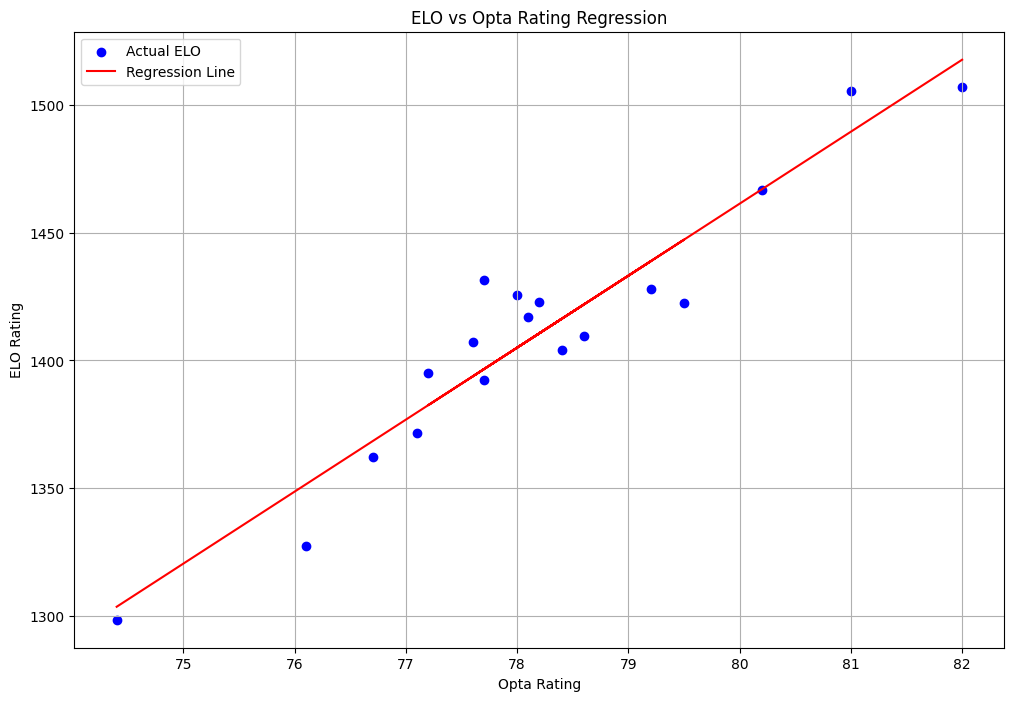

In [7]:
main_regression(**CONFIG)

In [8]:
standings_df, fixtures_matrix = build_historical_standings_table_after_at_most_n_rounds(**CONFIG)
standings_df.head(CONFIG['head_size'])

,Club,Elo,Matches played,Wins,Draws,Losses,Goals for,Goals against,Goal difference,Goals away,Points,Random order,H2H
1,Lech Poznan,1517.88,27,12,9,6,46,37,9,17,45,3,1
2,Gornik Zabrze,1447.34,27,12,6,9,39,32,7,12,42,4,1
3,Jagiellonia,1467.09,27,11,9,7,43,34,9,14,42,12,2
4,Zaglebie Lubin,1410.66,27,11,8,8,41,33,8,17,41,1,1
5,Wisla Plock,1379.62,27,10,9,8,28,26,2,13,39,11,1
6,Raków Częstochowa,1489.66,27,11,6,10,36,34,2,22,39,17,2
7,GKS Katowice,1421.94,27,12,3,12,36,35,1,15,39,2,3
8,Motor Lublin,1396.55,27,9,11,7,36,39,-3,17,38,6,1
9,Lechia Gdansk,1416.30,27,12,6,9,55,50,5,22,37,14,1
10,Cracovia Krakow,1407.83,27,9,9,9,31,31,0,14,36,7,1


In [9]:
CONFIG['update_fixtures'] = False

In [10]:
standings_df['Elo'].mean()

np.float64(1410.8127777777781)

In [11]:
float(round(standings_df['Points'].sum() / standings_df['Matches played'].sum(), 2))

Failed to reload module 'sims_engine' from file 'd:\HugePythonProjects\outrights-pred\src\sims_engine.py'
Traceback (most recent call last):
  File "d:\HugePythonProjects\outrights-pred\.venv\Lib\site-packages\IPython\extensions\autoreload.py", line 325, in check
    superreload(m, reload, self.old_objects)
  File "d:\HugePythonProjects\outrights-pred\.venv\Lib\site-packages\IPython\extensions\autoreload.py", line 584, in superreload
    module = reload(module)
             ^^^^^^^^^^^^^^
  File "C:\Users\micha\anaconda3\Lib\importlib\__init__.py", line 169, in reload
    _bootstrap._exec(spec, module)
  File "<frozen importlib._bootstrap>", line 621, in _exec
  File "<frozen importlib._bootstrap_external>", line 940, in exec_module
  File "<frozen importlib._bootstrap>", line 241, in _call_with_frames_removed
  File "d:\HugePythonProjects\outrights-pred\src\sims_engine.py", line 50, in <module>
    [
  File "d:\HugePythonProjects\outrights-pred\src\sims_engine.py", line 51, in <listco

1.35

In [12]:
sample_season = simulate_season_after_n_rounds(**CONFIG, standings_df=standings_df)
sample_season.head(CONFIG['head_size'])

,Club,Elo,Matches played,Wins,Draws,Losses,Goals for,Goals against,Goal difference,Goals away,Points,Random order,H2H
1,Lech Poznan,1517.88,34,15,12,7,55,42,13,21,57,8,1
2,Raków Częstochowa,1489.66,34,15,9,10,47,37,10,26,54,0,1
3,Zaglebie Lubin,1410.66,34,15,8,11,49,39,10,19,53,11,1
4,Wisla Plock,1379.62,34,14,11,9,38,30,8,18,53,17,2
5,Gornik Zabrze,1447.34,34,15,8,11,47,38,9,17,53,7,3
6,Cracovia Krakow,1407.83,34,13,12,9,42,34,8,19,51,3,1
7,GKS Katowice,1421.94,34,15,4,15,43,42,1,17,49,2,1
8,Lechia Gdansk,1416.30,34,15,8,11,63,56,7,25,48,5,1
9,Piast Gliwice,1405.01,34,14,5,15,42,42,0,21,47,4,1
10,Legia Warszawa,1438.87,34,11,14,9,42,35,7,19,47,12,2


In [13]:
float(round(sample_season['Points'].sum() / sample_season['Matches played'].sum(), 2))

1.36

In [14]:
simulate_odds(**CONFIG, standings_df=standings_df).head(CONFIG['head_size'])

,Home Team,Away Team,Odds H,Odds D,Odds A
0,GKS Katowice,Wisla Plock,2.12,3.66,3.91
1,Raków Częstochowa,Widzew Łódź,1.76,4.21,5.19
2,Gornik Zabrze,Cracovia Krakow,2.13,3.65,3.89
3,Jagiellonia,Lech Poznan,2.70,3.43,2.95
4,Nieciecza,Piast Gliwice,3.21,3.46,2.50
5,Radomiak Radom,Motor Lublin,2.47,3.47,3.26
6,Pogon Szczecin,Legia Warszawa,2.66,3.43,3.00
7,Lechia Gdansk,Korona Kielce,2.23,3.58,3.67
8,Arka Gdynia,Zaglebie Lubin,2.81,3.42,2.84


In [15]:
# full table sim
results = run_full_table_sims(**CONFIG, standings_df=standings_df, fixtures_matrix=fixtures_matrix)
results.head(CONFIG['head_size'])

100%|██████████| 10000/10000 [04:16<00:00, 38.96it/s]


10000 simulations


,Club,Elo,xPts,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
1,Lech Poznan,1517.88,57.36,69.2,17.6,6.9,3.3,1.6,0.8,0.4,0.2,0.1,0.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Jagiellonia,1467.09,52.46,10.8,22.4,17.8,14.7,10.6,8.3,5.9,4.0,2.6,1.4,0.9,0.3,0.2,0.1,0.1,0.0,0.0,0.0
3,Gornik Zabrze,1447.34,52.26,8.2,22.3,19.7,14.7,10.9,8.4,5.6,4.1,2.5,1.8,0.8,0.5,0.2,0.1,0.0,0.0,0.0,0.0
4,Zaglebie Lubin,1410.66,50.81,4.9,13.6,15.4,14.6,12.3,10.7,8.4,6.8,4.6,3.1,2.3,1.6,0.9,0.5,0.1,0.0,0.0,0.0
5,Raków Częstochowa,1489.66,50.48,2.9,10.9,14.8,15.0,13.2,10.2,8.9,6.8,5.5,4.3,2.7,1.9,1.5,0.8,0.4,0.2,0.1,0.0
6,GKS Katowice,1421.94,48.57,1.5,4.5,7.1,9.5,11.4,11.5,11.2,9.7,8.5,7.4,6.1,4.5,3.2,2.1,1.2,0.4,0.1,0.0
7,Wisla Plock,1379.62,48.10,1.2,3.5,6.9,8.2,9.9,11.1,11.2,10.5,9.4,7.8,6.6,5.2,3.9,2.1,1.5,0.8,0.2,0.0
8,Lechia Gdansk,1416.30,46.75,0.4,1.7,3.5,5.0,7.4,8.6,9.8,9.8,10.0,10.2,8.9,7.9,6.0,5.0,3.3,1.8,0.7,0.0
9,Motor Lublin,1396.55,46.57,0.4,1.5,2.8,4.9,6.7,7.6,9.2,10.5,9.9,9.9,9.7,9.0,6.4,5.4,3.7,1.9,0.6,0.0
10,Cracovia Krakow,1407.83,45.82,0.2,0.7,1.9,3.3,4.8,7.0,8.2,8.6,9.7,10.0,9.8,8.8,8.4,7.3,5.9,3.9,1.4,0.0


In [16]:
# top 1, 2, 3, 4 sim
results = run_top_n_sims(**CONFIG, standings_df=standings_df, fixtures_matrix=fixtures_matrix, top_n=[1, 2, 3, 4])
results.head(CONFIG['head_size'])

 11%|█▏        | 1145/10000 [00:25<03:14, 45.61it/s]


KeyboardInterrupt: 

In [ ]:
# bottom 1, 3 sim
results = run_top_n_sims(**CONFIG, standings_df=standings_df, fixtures_matrix=fixtures_matrix, top_n=[1, 3], reverse=True)
results.head(CONFIG['head_size'])

100%|██████████| 10000/10000 [04:58<00:00, 33.49it/s]

10000 simulations
Top N: [1, 3]
Reverse: TRUE


,Club,Elo,xPts,Top 1 %,Top 1 Odds,Top 3 %,Top 3 Odds
1,Nieciecza,1303.43,32.28,87.5,1.14,98.6,1.01
2,Widzew Łódź,1368.33,39.20,6.8,14.71,62.0,1.61
3,Arka Gdynia,1351.40,40.58,3.6,27.78,49.4,2.02
4,Legia Warszawa,1438.87,43.37,0.8,125.0,15.4,6.49
5,Radomiak Radom,1382.44,42.51,0.7,142.86,23.6,4.24
6,Pogon Szczecin,1396.55,42.62,0.5,200.0,22.5,4.44
7,Piast Gliwice,1405.01,44.68,0.1,1000.0,10.1,9.9
8,Korona Kielce,1393.73,44.96,0.1,1000.0,6.1,16.39
9,Jagiellonia,1467.09,52.40,0.0,N/A,0.0,N/A
10,Lech Poznan,1517.88,57.43,0.0,N/A,0.0,N/A
